<a href="https://colab.research.google.com/github/Taniya-roy20/ML-PROJECT/blob/main/SVM_AND_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving 11_mushroom_edibility.csv to 11_mushroom_edibility.csv


In [2]:
import pandas as pd

df = pd.read_csv("11_mushroom_edibility.csv")

df.head()


,SampleID,CapShape,CapColor,Odor,GillSpacing,GillColor,StalkShape,RingNumber,Habitat,Population,Class
0,S0001,flat,gray,foul,crowded,brown,tapering,one,woods,scattered,poisonous
1,S0002,convex,brown,almond,close,white,tapering,none,grasses,several,edible
2,S0003,convex,gray,none,distant,black,enlarging,two,leaves,scattered,poisonous
3,S0004,flat,yellow,none,close,white,enlarging,one,woods,abundant,poisonous
4,S0005,knobbed,gray,fishy,close,pink,enlarging,one,urban,several,poisonous


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["Class"].value_counts())

Shape: (600, 11)

Columns:
Index(['SampleID', 'CapShape', 'CapColor', 'Odor', 'GillSpacing', 'GillColor',
       'StalkShape', 'RingNumber', 'Habitat', 'Population', 'Class'],
      dtype='object')

Missing values:
SampleID       0
CapShape       0
CapColor       0
Odor           0
GillSpacing    0
GillColor      0
StalkShape     0
RingNumber     0
Habitat        0
Population     0
Class          0
dtype: int64

Class distribution:
Class
poisonous    347
edible       253
Name: count, dtype: int64


In [4]:
X = df.drop(columns=["Class", "SampleID"])
y = df["Class"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['CapShape', 'CapColor', 'Odor', 'GillSpacing', 'GillColor',
       'StalkShape', 'RingNumber', 'Habitat', 'Population'],
      dtype='object')

Target:
Class


In [5]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

label_encoders = {}

for column in X_encoded.columns:
    le = LabelEncoder()
    X_encoded[column] = le.fit_transform(X_encoded[column])
    label_encoders[column] = le

# Encode target variable
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print(X_encoded.head())
print("\nEncoded classes:", target_encoder.classes_)

   CapShape  CapColor  Odor  GillSpacing  GillColor  StalkShape  RingNumber  \
0         2         1     3            1          1           1           1   
1         1         0     0            0          4           1           0   
2         1         1     4            2          0           0           2   
3         2         4     4            0          4           0           1   
4         3         1     2            0          3           0           1   

   Habitat  Population  
0        4           1  
1        0           2  
2        1           1  
3        4           0  
4        3           2  

Encoded classes: ['edible' 'poisonous']


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (480, 9)
Testing data: (120, 9)


In [7]:
from sklearn.svm import SVC

svm_model = SVC(kernel="linear", random_state=42)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)
print("SVM Accuracy (%):", svm_accuracy * 100)

SVM Accuracy: 0.675
SVM Accuracy (%): 67.5


In [9]:
from sklearn.metrics import classification_report

print("SVM Classification Report:")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=target_encoder.classes_
))

SVM Classification Report:
              precision    recall  f1-score   support

      edible       0.68      0.45      0.54        51
   poisonous       0.67      0.84      0.75        69

    accuracy                           0.68       120
   macro avg       0.68      0.65      0.64       120
weighted avg       0.68      0.68      0.66       120



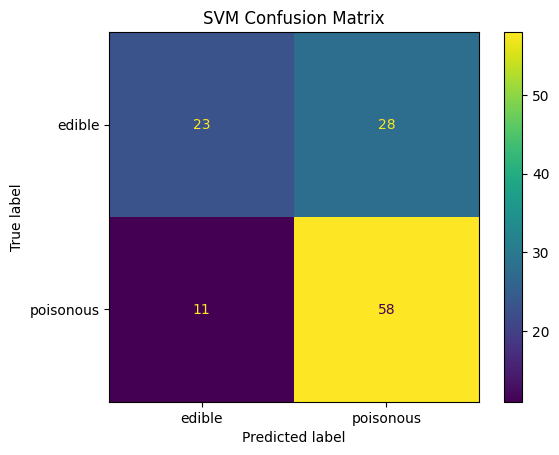

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=target_encoder.classes_
)

disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

**KNN**

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

In [13]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)
print("KNN Accuracy (%):", knn_accuracy * 100)

KNN Accuracy: 0.6083333333333333
KNN Accuracy (%): 60.83333333333333


In [14]:
print("KNN Classification Report:")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=target_encoder.classes_
))

KNN Classification Report:
              precision    recall  f1-score   support

      edible       0.54      0.51      0.53        51
   poisonous       0.65      0.68      0.67        69

    accuracy                           0.61       120
   macro avg       0.60      0.60      0.60       120
weighted avg       0.61      0.61      0.61       120



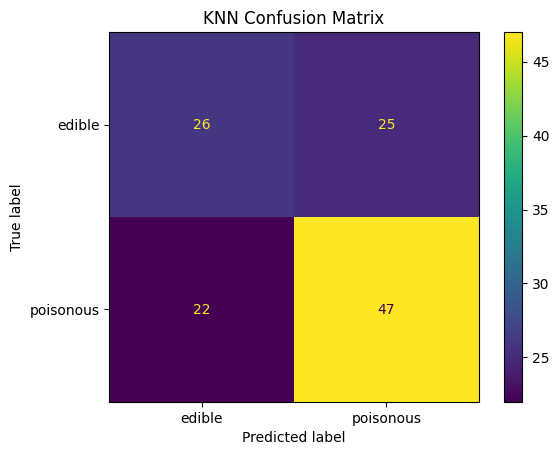

In [15]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=target_encoder.classes_
)

disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()

**BEST K** **VALUE**

In [16]:
k_values = range(1, 21)
k_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    prediction = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, prediction)

    k_accuracies.append(accuracy)

print("K values:", list(k_values))
print("Accuracies:", k_accuracies)

K values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Accuracies: [0.5333333333333333, 0.5416666666666666, 0.575, 0.5583333333333333, 0.6083333333333333, 0.6083333333333333, 0.6416666666666667, 0.625, 0.625, 0.6333333333333333, 0.6166666666666667, 0.6416666666666667, 0.6416666666666667, 0.6333333333333333, 0.6583333333333333, 0.6333333333333333, 0.6416666666666667, 0.6166666666666667, 0.6416666666666667, 0.625]


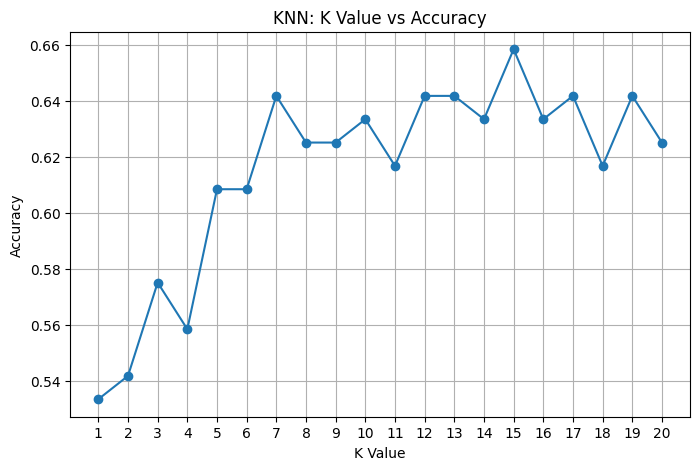

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, k_accuracies, marker="o")

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN: K Value vs Accuracy")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [18]:
best_k = k_values[k_accuracies.index(max(k_accuracies))]
best_accuracy = max(k_accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)
print("Best Accuracy (%):", best_accuracy * 100)

Best K: 15
Best Accuracy: 0.6583333333333333
Best Accuracy (%): 65.83333333333333


In [19]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(X_train_scaled, y_train)

final_knn_prediction = final_knn.predict(X_test_scaled)

final_knn_accuracy = accuracy_score(
    y_test,
    final_knn_prediction
)

print("Final KNN Accuracy:", final_knn_accuracy)
print("Final KNN Accuracy (%):", final_knn_accuracy * 100)

Final KNN Accuracy: 0.6583333333333333
Final KNN Accuracy (%): 65.83333333333333


In [20]:
results = pd.DataFrame({
    "Algorithm": [
        "SVM",
        "KNN"
    ],
    "Accuracy": [
        svm_accuracy,
        final_knn_accuracy
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

results

,Algorithm,Accuracy,Accuracy (%)
0,SVM,0.675000,67.500000
1,KNN,0.658333,65.833333
